In [1]:
import numpy as np
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('AEP_hourly_full.csv', sep=',')
df = df[(df.Datetime >= '2011-02-01 00:00:00') & \
    (df.Datetime < '2011-05-21 00:00:00')]

df = df.rename(columns={'AEP_MW': 'y'})
df = df.rename(columns={'Datetime': 'ds'})
df.index = pd.to_datetime(df.ds, dayfirst=True, \
    infer_datetime_format=True)
df = df.sort_index()

In [3]:
# %% split the data
X_train = df.iloc[:-(20*24)]
X_test = df.iloc[-(20*24):]

In [4]:
# Build and fit the Prophet model
prophet_mod = Prophet(
    growth='linear',
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='additive'
)


# Fit the model on the training data
prophet_mod.fit(X_train)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [5]:
prophet_fit = prophet_mod.\
    predict(X_train).\
    yhat.\
    set_axis(df.index[:len(X_train)])
df['y_fit'] = prophet_fit


In [6]:
prophet_fc = prophet_mod.\
    predict(X_test).\
    yhat.\
    set_axis(df.index[len(X_train):])
df['y_fc'] = prophet_fc

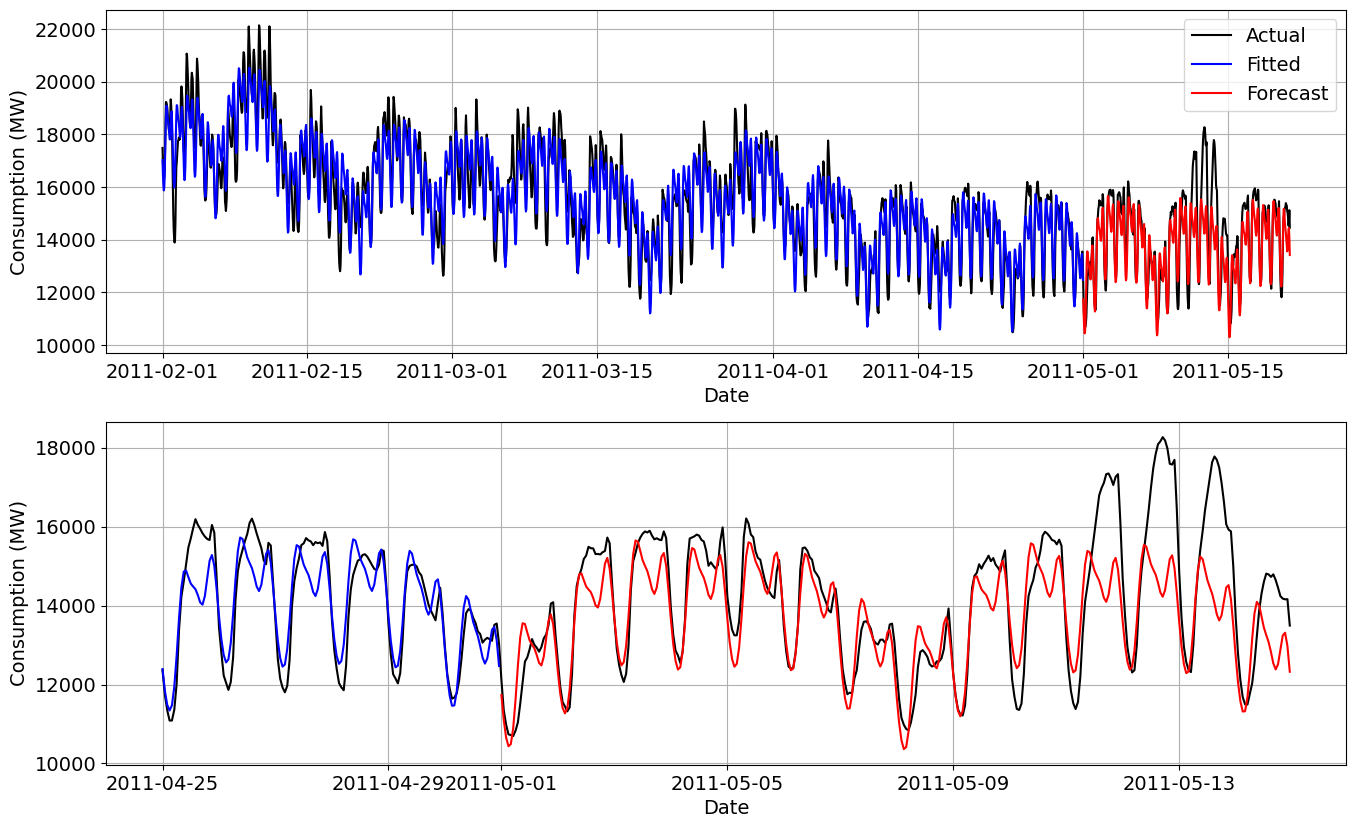

In [7]:
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2) = plt.subplots(2, \
    figsize=(16, 10), dpi=100)

# observed data
ax1.plot(df.index, df.y, \
    color='k', label='Actual')

# fitted values
ax1.plot(df.index, df.y_fit, \
    color='b', label='Fitted')

# forecasted values
ax1.plot(df.index, df.y_fc, \
    color='r', label='Forecast')

# set artists
ax1.set_xlabel('Date')
ax1.set_ylabel('Consumption (MW)')
ax1.grid()
ax1.legend()

# second plot - zoom to 10 days
df_zoom = df[(df.ds >= '2011-04-25 00:00:00') & \
    (df.ds < '2011-05-15 00:00:00')]

# observed data
ax2.plot(df_zoom.index, df_zoom.y, \
    color='k', label='Actual')

# fitted values
ax2.plot(df_zoom.index, df_zoom.y_fit, \
    color='b', label='Fitted')

# forecasted values
ax2.plot(df_zoom.index, df_zoom.y_fc, \
    color='r', label='Forecast')

# set artists
ax2.set_xlabel('Date')
ax2.set_ylabel('Consumption (MW)')
ax2.grid()

plt.show()


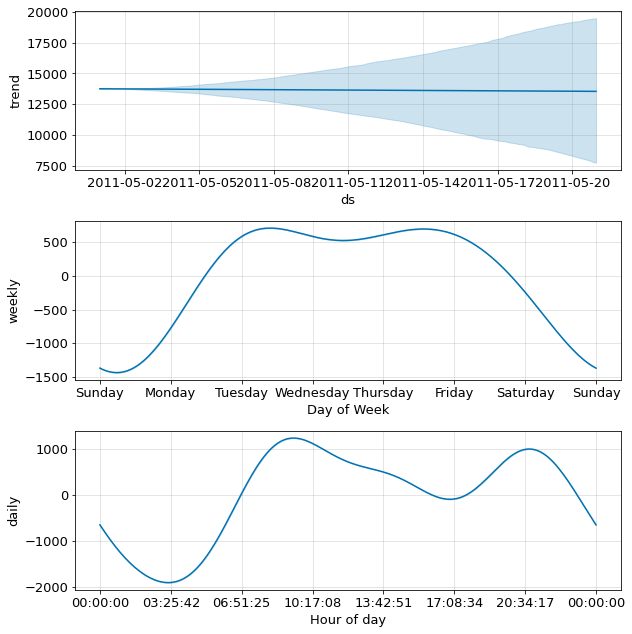

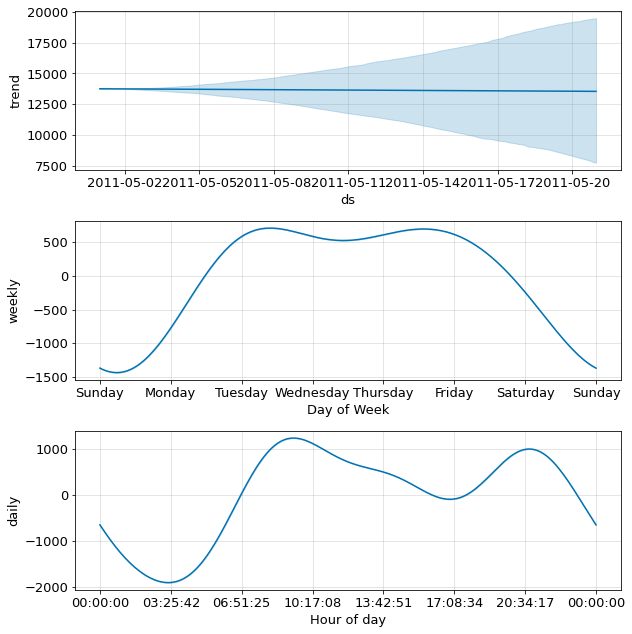

In [8]:
plt.rcParams.update({'font.size': 13})
prophet_mod.plot_components( \
    prophet_mod.predict(X_test))